# Two-Stage NSBH Impact: f_j^{BNS} Comparison (Universal Angle Geometry)

Compare Stage 2 posteriors for BNS and NSBH angles across three f_j^{BNS} values:
- f_j^{BNS} = 0.1
- f_j^{BNS} = 0.5
- f_j^{BNS} = 1.0

This notebook uses the universal-angle geometric efficiency (fixed top-hat beaming fraction).

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys

sys.path.insert(0, '../..')

plt.style.use('../../configurations/style.mplstyle')
datafiles = Path('../../datafiles')

from src.nsbh.init import initialize_combined_simulation
from src.top_hat.montecarlo import (
    create_k_interpolator,
    compute_luminosity_distance,
    simplified_montecarlo,
    apply_detection_cuts,
    score_func_cvm,
    poiss_log,
    run_mcmc,
    check_and_resume_mcmc,
)
from src.top_hat.geometric_eff import geometric_efficiency_fixed
from src.nsbh.montecarlo import GBM_EFF, FJ_NSBH_FIXED, N_MC_EVENTS
from scipy.stats import gaussian_kde
import src.init

print('Imports complete.')

Imports complete.


In [2]:
# Shared population setup (run once)
demo_params = {
    'alpha': -0.6,
    'beta_s': -2.5,
    'n': 2.0,
    'theta_c': 3.4,
    'theta_v_max': 10.0,
    'z_model': 'fiducial_delayed_A0.5',
}

bns_params, nsbh_data, data_dict = initialize_combined_simulation(
    datafiles=datafiles,
    params=demo_params,
    size_test=2_000,
    nsbh_population='fiducial_delayed_cut',
    nsbh_alpha='A0.5',
)

k_interpolator = create_k_interpolator()
bns_distances = compute_luminosity_distance(bns_params.z_arr)
nsbh_distances = nsbh_data.distances

print(f'FJ_NSBH fixed  = {FJ_NSBH_FIXED}')
print(f'BNS population size  = {len(bns_params.z_arr)}')
print(f'NSBH population size = {len(nsbh_data.z_arr)}')
print(f'Observed yearly GRB rate = {bns_params.yearly_rate:.2f}')

Using redshift model: samples_fiducial_delayed_A0.5_BNSs_0.dat with 60187 BNSs.
Computed total merger rate: 60477.4 yr^-1 (local R_0 = 22.7 Gpc^-3 yr^-1) for component BNSs
Generating temporal interpolators... (this may take a moment)
Preparing catalogue with limits: {'F_LIM': 4, 'T90_LIM': 2, 'EP_LIM_UPPER': 10000, 'EP_LIM_LOWER': 50}
Triggered events: 325, Trigger years: 17.50, Yearly rate: 18.58 events/year
Computed total merger rate: 18332.3 yr^-1 (local R_0 = 3.8 Gpc^-3 yr^-1) for component BHNSs
NSBH population: fiducial_delayed_cut / A0.5
  BHNSs local rate R_0 = 3.8 Gpc^-3 yr^-1
  BHNSs total rate     = 18332 yr^-1
  1-year z sample size = 18332
FJ_NSBH fixed  = 1
BNS population size  = 60187
NSBH population size = 18332
Observed yearly GRB rate = 18.58


## Stage 1 + Stage 2 for each f_j^{BNS}

Stage 1 (BNS-only) and Stage 2 (BNS+NSBH) are run independently for each fixed f_j^{BNS}.

In [3]:
# Dictionary to store results for each fj_bns value
results_by_fj = {}

FJ_BNS_VALUES = [0.1, 0.5, 1.0]
N_PARAMS_1 = 5
N_WALKERS_1 = 24
N_STEPS_1 = 5000
N_PARAMS_2 = 2
N_WALKERS_2 = 24
N_STEPS_2 = 5000
burn_frac = 0.33
thin = 10

for fj_bns in FJ_BNS_VALUES:
    print(f'\n{"="*60}')
    print(f'Running for FJ_BNS = {fj_bns}')
    print(f'{"="*60}')

    run_name_stage1 = f'universal_stage1_bns_only_fj{fj_bns:.1f}'
    out_dir_stage1 = src.init.create_run_dir(run_name_stage1, output_files_default='Output_files')
    backend_path_stage1 = out_dir_stage1 / 'emcee.h5'

    def log_likelihood_stage1_bns_only(thetas, n_events=N_MC_EVENTS, fj=fj_bns):
        A_index, L_L0, L_mu_E, sigma_E, theta_c_bns = thetas
        grb_thetas = [A_index, L_L0, L_mu_E, sigma_E]

        geom_eff_bns = geometric_efficiency_fixed(theta_c_bns)
        epsilon_bns = geom_eff_bns * fj
        intrinsic_bns = epsilon_bns * len(bns_params.z_arr) * GBM_EFF

        bns_results = simplified_montecarlo(
            grb_thetas, n_events, bns_params, bns_distances, k_interpolator
        )
        bns_trig, bns_analysis = apply_detection_cuts(
            bns_results['p_flux'], bns_results['E_p_obs']
        )

        pflux_det = bns_results['p_flux'][bns_analysis]
        epeak_det = bns_results['E_p_obs'][bns_analysis]
        if len(pflux_det) <= 3:
            return -np.inf, -np.inf, -np.inf, -np.inf, -np.inf

        logL_pflux = score_func_cvm(pflux_det, bns_params.pflux_data, bns_params.rng)
        logL_epeak = score_func_cvm(epeak_det, bns_params.epeak_data, bns_params.rng)

        phys_eff_bns = np.sum(bns_trig) / n_events
        predicted_bns = intrinsic_bns * bns_params.triggered_years * phys_eff_bns

        observed_total = bns_params.yearly_rate * bns_params.triggered_years
        if predicted_bns <= 0:
            return -np.inf, -np.inf, -np.inf, -np.inf, -np.inf

        logL_poisson = poiss_log(k=observed_total, mu=predicted_bns)
        logL_total = logL_pflux + logL_epeak + logL_poisson

        return logL_total, logL_pflux, logL_epeak, logL_poisson, predicted_bns

    def log_prior_stage1(thetas):
        A_index, L_L0, L_mu_E, sigma_E, theta_c_bns = thetas

        if not (1.5 < A_index < 12):
            return -np.inf
        if not (-2 < L_L0 < 7):
            return -np.inf
        if not (0.1 < L_mu_E < 7):
            return -np.inf
        if not (0 < sigma_E < 2.5):
            return -np.inf
        if not (1 < theta_c_bns < 50):
            return -np.inf

        return 0.0

    def init_walkers_stage1(n_walkers, seed=123):
        rng = np.random.default_rng(seed)
        return np.column_stack([
            rng.uniform(2.0, 3.5, n_walkers),
            rng.uniform(2.0, 4.5, n_walkers),
            rng.uniform(1.5, 4.5, n_walkers),
            rng.uniform(0.2, 1.2, n_walkers),
            rng.uniform(3.0, 20.0, n_walkers),
        ])

    def log_probability_stage1(thetas):
        lp = log_prior_stage1(thetas)
        if not np.isfinite(lp):
            return -np.inf, 0.0, 0.0, 0.0, 0.0

        ll = log_likelihood_stage1_bns_only(thetas=thetas, n_events=N_MC_EVENTS, fj=fj_bns)
        if not np.isfinite(ll[0]):
            return -np.inf, 0.0, 0.0, 0.0, 0.0

        return lp + ll[0], ll[1], ll[2], ll[3], ll[4]

    initial_pos_1, n_steps_rem_1, backend_1 = check_and_resume_mcmc(
        filename=backend_path_stage1,
        n_steps=N_STEPS_1,
        initialize_walkers_func=init_walkers_stage1,
        n_walkers=N_WALKERS_1,
    )

    run_mcmc(
        log_probability_func=log_probability_stage1,
        initial_walkers=initial_pos_1,
        n_iterations=n_steps_rem_1,
        n_walkers=N_WALKERS_1,
        n_params=N_PARAMS_1,
        backend=backend_1,
        blobs_dtype=[('l_pflux', float), ('l_epeak', float), ('l_poiss', float), ('mu_bns', float)],
    )

    flat_1 = backend_1.get_chain(discard=int(backend_1.iteration * burn_frac), thin=thin, flat=True)
    medians_1 = np.median(flat_1, axis=0)
    spectral_fixed = medians_1[:4].copy()
    theta_bns_stage1_med = medians_1[4]

    print(f'Stage 1 theta_c^BNS median = {theta_bns_stage1_med:.3f} deg')

    run_name_stage2 = f'universal_stage2_bns_plus_nsbh_fj{fj_bns:.1f}'
    out_dir_stage2 = src.init.create_run_dir(run_name_stage2, output_files_default='Output_files')
    backend_path_stage2 = out_dir_stage2 / 'emcee.h5'

    def log_likelihood_stage2_fixed_spectral(thetas, spectral_fixed, n_events=N_MC_EVENTS, fj=fj_bns):
        theta_c_bns, theta_c_nsbh = thetas
        A_index, L_L0, L_mu_E, sigma_E = spectral_fixed
        grb_thetas = [A_index, L_L0, L_mu_E, sigma_E]

        geom_eff_bns = geometric_efficiency_fixed(theta_c_bns)
        geom_eff_nsbh = geometric_efficiency_fixed(theta_c_nsbh)

        epsilon_bns = geom_eff_bns * fj
        epsilon_nsbh = geom_eff_nsbh * FJ_NSBH_FIXED

        intrinsic_bns = epsilon_bns * len(bns_params.z_arr) * GBM_EFF
        intrinsic_nsbh = epsilon_nsbh * len(nsbh_data.z_arr) * GBM_EFF

        bns_results = simplified_montecarlo(
            grb_thetas, n_events, bns_params, bns_distances, k_interpolator
        )
        bns_trig, bns_analysis = apply_detection_cuts(
            bns_results['p_flux'], bns_results['E_p_obs']
        )

        nsbh_results = simplified_montecarlo(
            grb_thetas, n_events, nsbh_data, nsbh_distances, k_interpolator, rng=bns_params.rng
        )
        nsbh_trig, nsbh_analysis = apply_detection_cuts(
            nsbh_results['p_flux'], nsbh_results['E_p_obs']
        )

        pflux_det = np.concatenate([
            bns_results['p_flux'][bns_analysis],
            nsbh_results['p_flux'][nsbh_analysis],
        ])
        epeak_det = np.concatenate([
            bns_results['E_p_obs'][bns_analysis],
            nsbh_results['E_p_obs'][nsbh_analysis],
        ])

        if len(pflux_det) <= 3:
            return -np.inf, -np.inf, -np.inf, -np.inf, -np.inf, -np.inf

        logL_pflux = score_func_cvm(pflux_det, bns_params.pflux_data, bns_params.rng)
        logL_epeak = score_func_cvm(epeak_det, bns_params.epeak_data, bns_params.rng)

        phys_eff_bns = np.sum(bns_trig) / n_events
        phys_eff_nsbh = np.sum(nsbh_trig) / n_events

        predicted_bns = intrinsic_bns * bns_params.triggered_years * phys_eff_bns
        predicted_nsbh = intrinsic_nsbh * bns_params.triggered_years * phys_eff_nsbh
        predicted_total = predicted_bns + predicted_nsbh

        observed_total = bns_params.yearly_rate * bns_params.triggered_years
        if predicted_total <= 0:
            return -np.inf, -np.inf, -np.inf, -np.inf, -np.inf, -np.inf

        logL_poisson = poiss_log(k=observed_total, mu=predicted_total)
        logL_total = logL_pflux + logL_epeak + logL_poisson

        return logL_total, logL_pflux, logL_epeak, logL_poisson, predicted_bns, predicted_nsbh

    def log_prior_stage2(thetas):
        theta_c_bns, theta_c_nsbh = thetas

        if not (1 < theta_c_bns < 50):
            return -np.inf
        if not (1 < theta_c_nsbh < 50):
            return -np.inf

        return 0.0

    def init_walkers_stage2(n_walkers, seed=321):
        rng = np.random.default_rng(seed)
        return np.column_stack([
            rng.uniform(max(1.2, theta_bns_stage1_med * 0.6), min(45.0, theta_bns_stage1_med * 1.4), n_walkers),
            rng.uniform(2.0, 25.0, n_walkers),
        ])

    def log_probability_stage2(thetas):
        lp = log_prior_stage2(thetas)
        if not np.isfinite(lp):
            return -np.inf, 0.0, 0.0, 0.0, 0.0, 0.0

        ll = log_likelihood_stage2_fixed_spectral(
            thetas=thetas,
            spectral_fixed=spectral_fixed,
            n_events=N_MC_EVENTS,
            fj=fj_bns,
        )
        if not np.isfinite(ll[0]):
            return -np.inf, 0.0, 0.0, 0.0, 0.0, 0.0

        return lp + ll[0], ll[1], ll[2], ll[3], ll[4], ll[5]

    initial_pos_2, n_steps_rem_2, backend_2 = check_and_resume_mcmc(
        filename=backend_path_stage2,
        n_steps=N_STEPS_2,
        initialize_walkers_func=init_walkers_stage2,
        n_walkers=N_WALKERS_2,
    )

    run_mcmc(
        log_probability_func=log_probability_stage2,
        initial_walkers=initial_pos_2,
        n_iterations=n_steps_rem_2,
        n_walkers=N_WALKERS_2,
        n_params=N_PARAMS_2,
        backend=backend_2,
        blobs_dtype=[('l_pflux', float), ('l_epeak', float), ('l_poiss', float), ('mu_bns', float), ('mu_nsbh', float)],
    )

    flat_2 = backend_2.get_chain(discard=int(backend_2.iteration * burn_frac), thin=thin, flat=True)
    theta_bns_2 = flat_2[:, 0]
    theta_nsbh_2 = flat_2[:, 1]

    results_by_fj[fj_bns] = {
        'theta_bns': theta_bns_2,
        'theta_nsbh': theta_nsbh_2,
    }

    print(f'Stage 2 theta_c^BNS median = {np.median(theta_bns_2):.3f} deg')
    print(f'Stage 2 theta_c^NSBH median = {np.median(theta_nsbh_2):.3f} deg')

print(f'\n{"="*60}')
print('All runs complete!')
print(f'{"="*60}')


Running for FJ_BNS = 0.1
Loading existing directory  : Output_files/universal_stage1_bns_only_fj0.1
Already completed this run


0it [00:00, ?it/s]


Stage 1 theta_c^BNS median = 23.785 deg
Loading existing directory  : Output_files/universal_stage2_bns_plus_nsbh_fj0.1
Already completed this run


0it [00:00, ?it/s]


Stage 2 theta_c^BNS median = 17.742 deg
Stage 2 theta_c^NSBH median = 10.616 deg

Running for FJ_BNS = 0.5
Loading existing directory  : Output_files/universal_stage1_bns_only_fj0.5
Already completed this run


...

Stage 2 theta_c^BNS median = 8.714 deg
Stage 2 theta_c^NSBH median = 15.230 deg

Running for FJ_BNS = 1.0
Loading existing directory  : Output_files/universal_stage1_bns_only_fj1.0
Already completed this run


0it [00:00, ?it/s]


Stage 1 theta_c^BNS median = 9.238 deg
Loading existing directory  : Output_files/universal_stage2_bns_plus_nsbh_fj1.0
Already completed this run


0it [00:00, ?it/s]

Stage 2 theta_c^BNS median = 6.259 deg
Stage 2 theta_c^NSBH median = 12.967 deg

All runs complete!


In [8]:
import emcee
fj_results_bns_only = {}

for fj_bns in FJ_BNS_VALUES:
    backend_path_stage1 = src.init.create_run_dir(
        f'universal_stage1_bns_only_fj{fj_bns:.1f}', output_files_default='Output_files'
    ) / 'emcee.h5'

    backend_1 = emcee.backends.HDFBackend(backend_path_stage1)
    flat_1 = backend_1.get_chain(discard=int(backend_1.iteration * burn_frac), thin=thin, flat=True)
    theta_bns_stage1 = flat_1[:, 4]

    fj_results_bns_only[fj_bns] = {
        'theta_bns': theta_bns_stage1,
    }

Loading existing directory  : Output_files/universal_stage1_bns_only_fj0.1
Loading existing directory  : Output_files/universal_stage1_bns_only_fj0.5
Loading existing directory  : Output_files/universal_stage1_bns_only_fj1.0


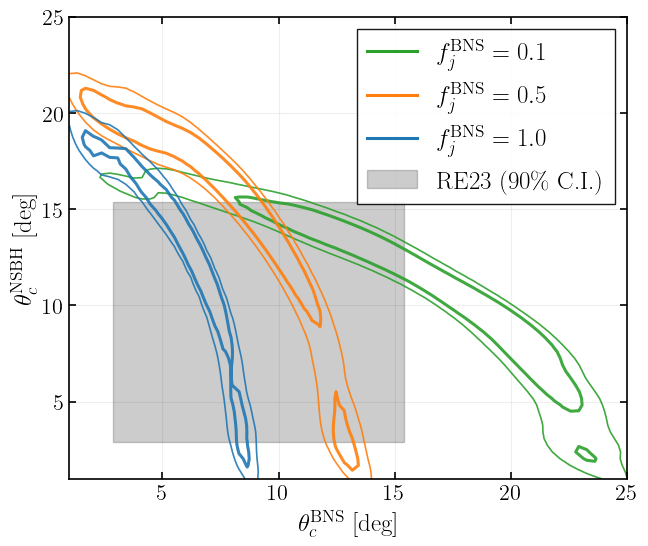

In [10]:
FS = 18

def contour_thresholds(density_values, probs=(0.68, 0.95)):
    vals = np.sort(density_values)[::-1]
    csum = np.cumsum(vals)
    csum /= csum[-1]
    return [vals[np.searchsorted(csum, p)] for p in probs]

fig, ax = plt.subplots(figsize=(7.2, 6.0))
colors = {0.1: 'tab:green', 0.5: 'tab:orange', 1.0: 'tab:blue'}

x = np.linspace(1, 25, 70)
y = np.linspace(1, 25, 70)
X, Y = np.meshgrid(x, y)
pos = np.vstack([X.ravel(), Y.ravel()])

RE_lims     = [6.1, -3.2, +9.3]
RE_median   = RE_lims[0]
RE_low      = RE_median + RE_lims[1]
RE_high     = RE_median + RE_lims[2]

for fj_bns in FJ_BNS_VALUES:
    theta_bns   = results_by_fj[fj_bns]['theta_bns']
    theta_nsbh  = results_by_fj[fj_bns]['theta_nsbh']
    xy          = np.vstack([theta_bns, theta_nsbh])
    kde         = gaussian_kde(xy)
    Z           = kde(pos).reshape(X.shape)

    sample_d = kde(xy)
    t68, t95 = contour_thresholds(sample_d, probs=(0.68, 0.95))

    ax.contour(X, Y, Z, 
    levels=[t95, t68], colors=[colors[fj_bns], colors[fj_bns]], 
    linewidths=[1.2, 2.2], alpha=0.9)

    #median_bns_only = np.median(fj_results_bns_only[fj_bns]['theta_bns'])
    #ax.axvline(median_bns_only, color=colors[fj_bns], linestyle='--', alpha=0.7)

label_collection = [] # for legend
from matplotlib.lines import Line2D
for fj_bns in FJ_BNS_VALUES:
    label = f'$f_j^{{\mathrm{{BNS}}}} = {fj_bns}$'
    line_fj = Line2D([0], [0], color=colors[fj_bns], lw=2.2, label=label)
    label_collection.append(line_fj)
    
from matplotlib.patches import Rectangle
rect = Rectangle((RE_low, RE_low), RE_high-RE_low, RE_high-RE_low, color='k', alpha=0.2)
ax.add_patch(rect)
label_collection.append(Rectangle((0, 0), 1, 1, color='k', alpha=0.2, label='RE23 (90\% C.I.)'))
ax.legend(handles=label_collection, loc='upper right', fontsize=FS)
ax.set_xlabel(r'$\theta_c^{\mathrm{BNS}}$ [deg]', fontsize=FS)
ax.set_ylabel(r'$\theta_c^{\mathrm{NSBH}}$ [deg]', fontsize=FS)
#set tick params
ax.tick_params(axis='both', which='major', labelsize=FS-2)
ax.grid(True, alpha=0.2)
ax.set_xlim(1, 25)
ax.set_ylim(1, 25)
plt.savefig('contour_plots_fj_comparison_universal.pdf', dpi=150, bbox_inches='tight')
plt.show()